# ☀️ Solar Power Generation — ML Prediction Pipeline
**Algorithm:** Random Forest Regressor (with GBM comparison)  
**Target:** `generated_power_kw`  
**Output:** `solar_model.sav` (pickled sklearn Pipeline)

In [1]:
# ─── 1. Imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [2]:
# ─── 2. Load Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('solarpowergeneration.csv')

print(f'Shape : {df.shape}')
print(f'Columns ({len(df.columns)}):', df.columns.tolist())
df.head()

Shape : (4213, 21)
Columns (21): ['temperature_2_m_above_gnd', 'relative_humidity_2_m_above_gnd', 'mean_sea_level_pressure_MSL', 'total_precipitation_sfc', 'snowfall_amount_sfc', 'total_cloud_cover_sfc', 'high_cloud_cover_high_cld_lay', 'medium_cloud_cover_mid_cld_lay', 'low_cloud_cover_low_cld_lay', 'shortwave_radiation_backwards_sfc', 'wind_speed_10_m_above_gnd', 'wind_direction_10_m_above_gnd', 'wind_speed_80_m_above_gnd', 'wind_direction_80_m_above_gnd', 'wind_speed_900_mb', 'wind_direction_900_mb', 'wind_gust_10_m_above_gnd', 'angle_of_incidence', 'zenith', 'azimuth', 'generated_power_kw']


,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_MSL,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
0,2.17,31,1035.0,0.0,0.0,0.0,0,0,0,0.00,...,312.71,9.36,22.62,6.62,337.62,24.48,58.753108,83.237322,128.33543,454.10095
1,2.31,27,1035.1,0.0,0.0,0.0,0,0,0,1.78,...,294.78,5.99,32.74,4.61,321.34,21.96,45.408585,75.143041,139.65530,1411.99940
2,3.65,33,1035.4,0.0,0.0,0.0,0,0,0,108.58,...,270.00,3.89,56.31,3.76,286.70,14.04,32.848282,68.820648,152.53769,2214.84930
3,5.82,30,1035.4,0.0,0.0,0.0,0,0,0,258.10,...,323.13,3.55,23.96,3.08,339.44,19.80,22.699288,64.883536,166.90159,2527.60920
4,7.73,27,1034.4,0.0,0.0,0.0,0,0,0,375.58,...,10.01,6.76,25.20,6.62,22.38,16.56,19.199908,63.795208,182.13526,2640.20340


In [3]:
# ─── 3. EDA ───────────────────────────────────────────────────────────────────
print('=== Statistical Summary ===')
display(df.describe())

print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Statistical Summary ===


,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_MSL,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
count,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,...,4213.000000,4213.000000,4213.000000,4213.00000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000
mean,15.068111,51.361025,1019.337812,0.031759,0.002808,34.056990,14.458818,20.023499,21.373368,387.759036,...,195.078452,18.978483,191.166862,16.36319,192.447911,20.583489,50.837490,59.980947,169.167651,1134.347313
std,8.853677,23.525864,7.022867,0.170212,0.038015,42.843638,30.711707,36.387948,38.013885,278.459293,...,106.626782,11.999960,108.760021,9.88533,106.516195,12.648899,26.638965,19.857711,64.568385,937.957247
min,-5.350000,7.000000,997.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.540000,0.000000,1.120000,0.00000,1.120000,0.720000,3.755323,17.727761,54.379093,0.000595
25%,8.390000,32.000000,1014.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,142.400000,...,153.190000,10.140000,130.240000,9.18000,148.220000,11.160000,29.408181,45.291631,114.136600,231.700450
50%,14.750000,48.000000,1018.100000,0.000000,0.000000,8.700000,0.000000,0.000000,0.000000,381.810000,...,191.770000,16.240000,187.770000,14.49000,187.990000,18.000000,47.335557,62.142611,163.241650,971.642650
75%,21.290000,70.000000,1023.600000,0.000000,0.000000,100.000000,9.000000,10.000000,10.000000,599.860000,...,292.070000,26.140000,292.040000,21.97000,288.000000,27.000000,69.197492,74.346737,225.085620,2020.966700
max,34.900000,100.000000,1046.800000,3.200000,1.680000,100.000000,100.000000,100.000000,100.000000,952.300000,...,360.000000,66.880000,360.000000,61.11000,360.000000,84.960000,121.635920,128.415370,289.045180,3056.794100



=== Missing Values ===
temperature_2_m_above_gnd            0
relative_humidity_2_m_above_gnd      0
mean_sea_level_pressure_MSL          0
total_precipitation_sfc              0
snowfall_amount_sfc                  0
total_cloud_cover_sfc                0
high_cloud_cover_high_cld_lay        0
medium_cloud_cover_mid_cld_lay       0
low_cloud_cover_low_cld_lay          0
shortwave_radiation_backwards_sfc    0
wind_speed_10_m_above_gnd            0
wind_direction_10_m_above_gnd        0
wind_speed_80_m_above_gnd            0
wind_direction_80_m_above_gnd        0
wind_speed_900_mb                    0
wind_direction_900_mb                0
wind_gust_10_m_above_gnd             0
angle_of_incidence                   0
zenith                               0
azimuth                              0
generated_power_kw                   0
dtype: int64


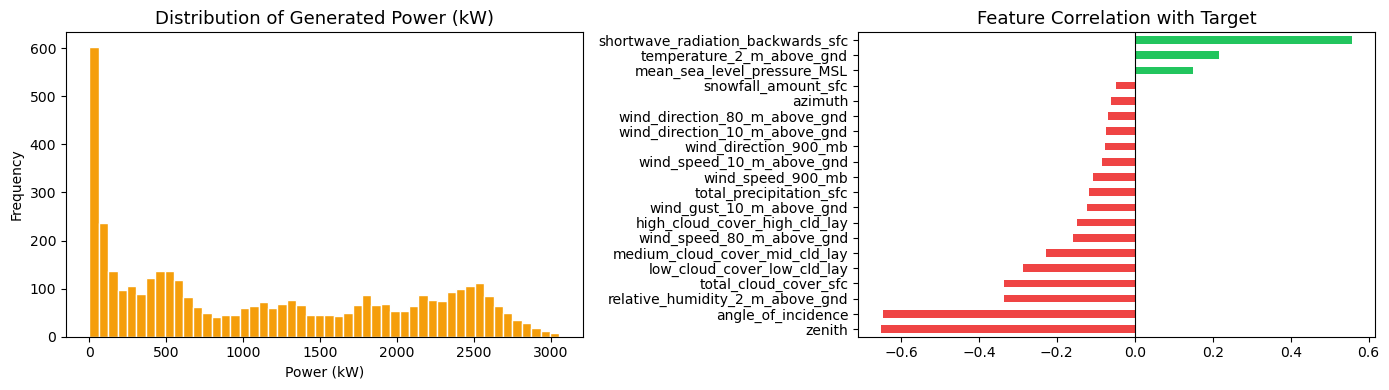

✅ Saved eda_plots.png


In [4]:
# Distribution of target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['generated_power_kw'], bins=50, color='#f59e0b', edgecolor='white')
axes[0].set_title('Distribution of Generated Power (kW)', fontsize=13)
axes[0].set_xlabel('Power (kW)')
axes[0].set_ylabel('Frequency')

# Top-10 feature correlations with target
corr = df.corr()['generated_power_kw'].drop('generated_power_kw').sort_values()
corr.plot(kind='barh', ax=axes[1], color=[
    '#ef4444' if v < 0 else '#22c55e' for v in corr
])
axes[1].set_title('Feature Correlation with Target', fontsize=13)
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print('✅ Saved eda_plots.png')

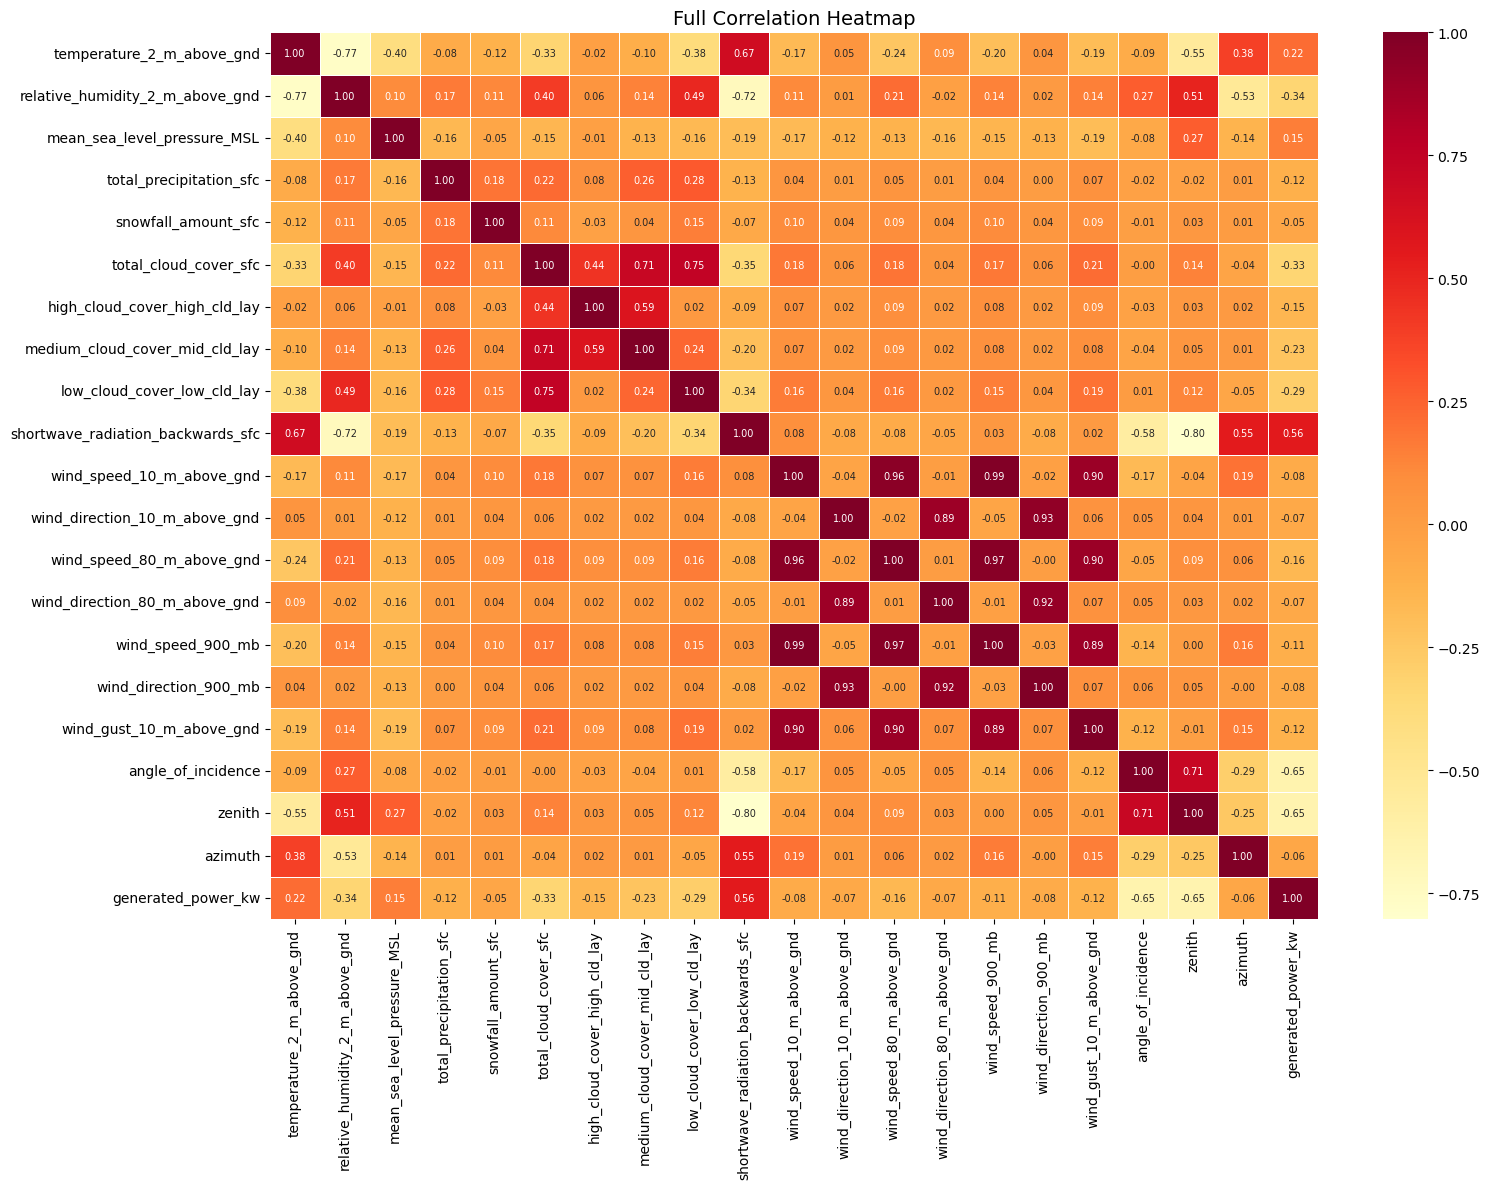

In [5]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.4, annot_kws={'size': 7})
plt.title('Full Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [6]:
# ─── 4. Feature / Target Split ────────────────────────────────────────────────
TARGET = 'generated_power_kw'

X = df.drop(columns=[TARGET])
y = df[TARGET]

FEATURE_NAMES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Features: {len(FEATURE_NAMES)}')

Train : 3370 samples
Test  : 843 samples
Features: 20


In [7]:
# ─── 5. Model 1 — Random Forest ───────────────────────────────────────────────
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestRegressor(
                   n_estimators=200,
                   max_depth=None,
                   min_samples_split=2,
                   min_samples_leaf=1,
                   random_state=42,
                   n_jobs=-1
               ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print('─── Random Forest ───')
print(f'  R²   : {rf_r2:.4f}')
print(f'  MAE  : {rf_mae:.4f} kW')
print(f'  RMSE : {rf_rmse:.4f} kW')

─── Random Forest ───
  R²   : 0.8216
  MAE  : 253.7006 kW
  RMSE : 403.7358 kW


In [8]:
# ─── 6. Model 2 — Gradient Boosting (comparison) ─────────────────────────────
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingRegressor(
                   n_estimators=200,
                   learning_rate=0.1,
                   max_depth=5,
                   random_state=42
               ))
])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

gb_r2   = r2_score(y_test, gb_pred)
gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print('─── Gradient Boosting ───')
print(f'  R²   : {gb_r2:.4f}')
print(f'  MAE  : {gb_mae:.4f} kW')
print(f'  RMSE : {gb_rmse:.4f} kW')

─── Gradient Boosting ───
  R²   : 0.8217
  MAE  : 258.4712 kW
  RMSE : 403.5333 kW


In [9]:
# ─── 7. Model Comparison Table ────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model' : ['Random Forest', 'Gradient Boosting'],
    'R²'    : [rf_r2,   gb_r2],
    'MAE'   : [rf_mae,  gb_mae],
    'RMSE'  : [rf_rmse, gb_rmse]
})
comparison = comparison.sort_values('R²', ascending=False).reset_index(drop=True)
print('=== Model Comparison ===')
display(comparison)

best_pipeline = rf_pipeline if rf_r2 >= gb_r2 else gb_pipeline
best_pred     = rf_pred     if rf_r2 >= gb_r2 else gb_pred
best_name     = 'Random Forest' if rf_r2 >= gb_r2 else 'Gradient Boosting'
best_r2       = max(rf_r2, gb_r2)
print(f'\n🏆 Best model: {best_name}  (R²={best_r2:.4f})')

=== Model Comparison ===


,Model,R²,MAE,RMSE
0,Gradient Boosting,0.821734,258.471153,403.533250
1,Random Forest,0.821555,253.700585,403.735787



🏆 Best model: Gradient Boosting  (R²=0.8217)


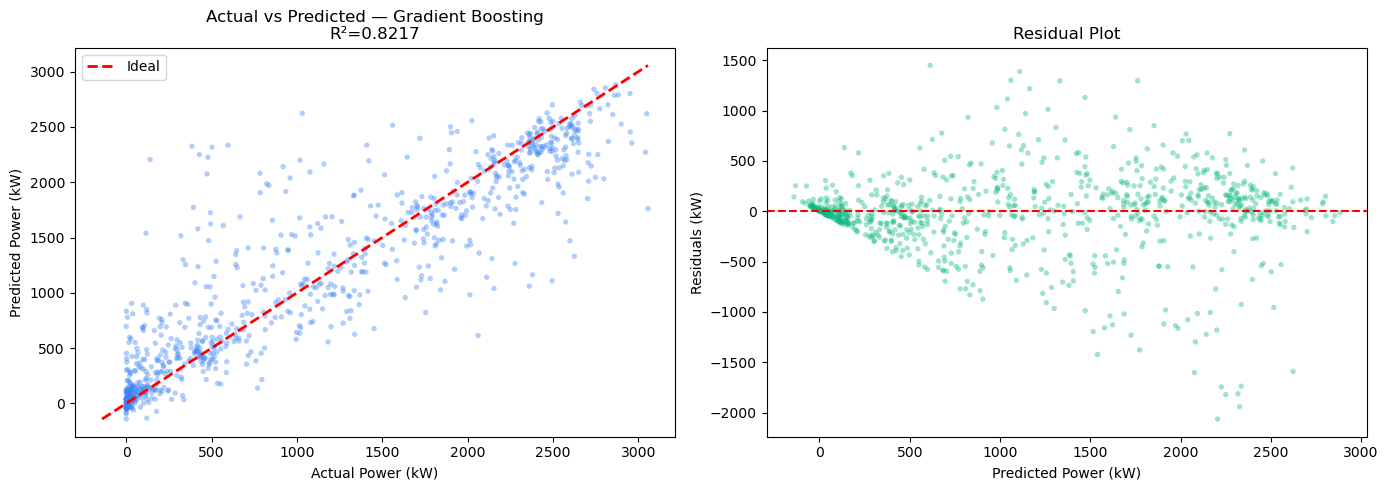

✅ Saved model_evaluation.png


In [10]:
# ─── 8. Evaluation Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.4, s=15,
                color='#3b82f6', edgecolors='none')
lims = [min(y_test.min(), best_pred.min()),
        max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Ideal')
axes[0].set_xlabel('Actual Power (kW)')
axes[0].set_ylabel('Predicted Power (kW)')
axes[0].set_title(f'Actual vs Predicted — {best_name}\nR²={best_r2:.4f}',
                  fontsize=12)
axes[0].legend()

# Residuals
residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.4, s=15,
                color='#10b981', edgecolors='none')
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Power (kW)')
axes[1].set_ylabel('Residuals (kW)')
axes[1].set_title('Residual Plot', fontsize=12)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()
print('✅ Saved model_evaluation.png')

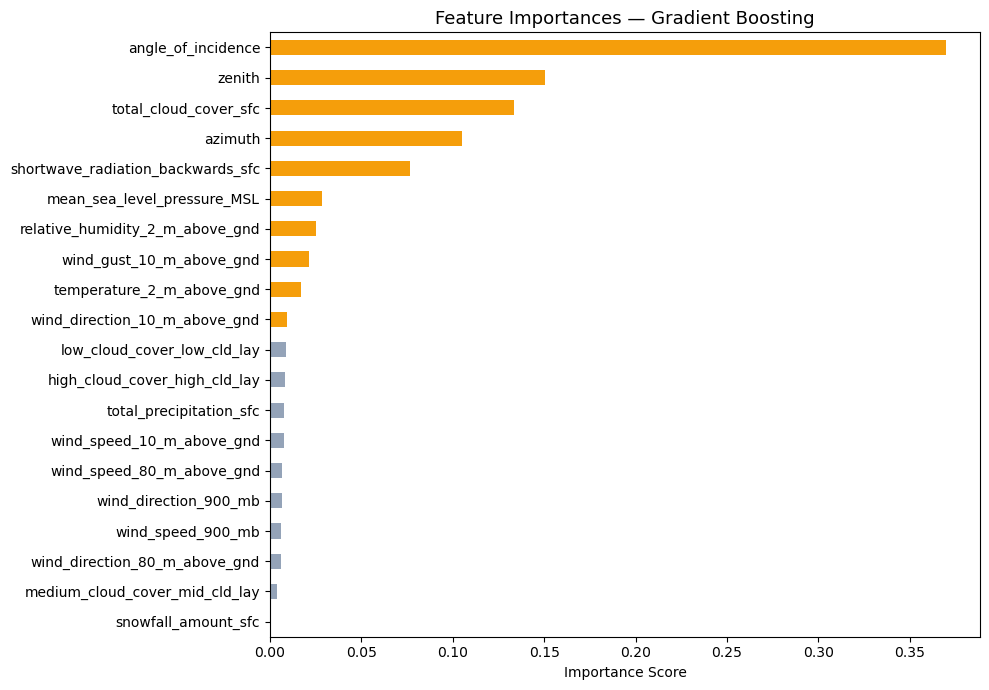

✅ Saved feature_importance.png


In [11]:
# ─── 9. Feature Importance ────────────────────────────────────────────────────
importances = best_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_NAMES).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#f59e0b' if v >= feat_imp.median() else '#94a3b8' for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title(f'Feature Importances — {best_name}', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('✅ Saved feature_importance.png')

In [12]:
# ─── 10. Cross-Validation ─────────────────────────────────────────────────────
cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='r2')
print(f'5-Fold CV R² scores : {cv_scores.round(4)}')
print(f'Mean R²             : {cv_scores.mean():.4f}')
print(f'Std R²              : {cv_scores.std():.4f}')

5-Fold CV R² scores : [0.4409 0.821  0.8253 0.7581 0.4797]
Mean R²             : 0.6650
Std R²              : 0.1693


In [13]:
# ─── 11. Save Model as .sav using Pickle ──────────────────────────────────────
MODEL_PATH = 'solar_model.sav'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f'✅ Model saved  →  {MODEL_PATH}')

# ── Verify it loads back correctly ──
with open(MODEL_PATH, 'rb') as f:
    loaded_model = pickle.load(f)

verify_pred = loaded_model.predict(X_test[:5])
print(f'\nVerification — sample predictions:')
for i, (actual, pred) in enumerate(zip(y_test.values[:5], verify_pred)):
    print(f'  Sample {i+1}: Actual={actual:.2f} kW  |  Predicted={pred:.2f} kW')

✅ Model saved  →  solar_model.sav

Verification — sample predictions:
  Sample 1: Actual=2511.24 kW  |  Predicted=2399.73 kW
  Sample 2: Actual=480.21 kW  |  Predicted=317.46 kW
  Sample 3: Actual=2017.57 kW  |  Predicted=1896.05 kW
  Sample 4: Actual=760.14 kW  |  Predicted=384.34 kW
  Sample 5: Actual=220.40 kW  |  Predicted=145.50 kW


In [14]:
# ─── 12. Summary ──────────────────────────────────────────────────────────────
print('=' * 50)
print('       PIPELINE SUMMARY')
print('=' * 50)
print(f'  Best Algorithm  : {best_name}')
print(f'  Features Used   : {len(FEATURE_NAMES)}')
print(f'  Train Samples   : {X_train.shape[0]}')
print(f'  Test Samples    : {X_test.shape[0]}')
print(f'  R² Score        : {best_r2:.4f}')
print(f'  MAE             : {rf_mae if best_name == "Random Forest" else gb_mae:.4f} kW')
print(f'  RMSE            : {rf_rmse if best_name == "Random Forest" else gb_rmse:.4f} kW')
print(f'  CV R² (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Saved model     : solar_model.sav')
print('=' * 50)

       PIPELINE SUMMARY
  Best Algorithm  : Gradient Boosting
  Features Used   : 20
  Train Samples   : 3370
  Test Samples    : 843
  R² Score        : 0.8217
  MAE             : 258.4712 kW
  RMSE            : 403.5333 kW
  CV R² (5-fold)  : 0.6650 ± 0.1693
  Saved model     : solar_model.sav
